In [12]:
!pip install datasets transformers sentencepiece sacrebleu torch gradio -q

In [14]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from transformers import T5ForConditionalGeneration, T5Tokenizer
from sacrebleu.metrics import BLEU
import gradio as gr

In [15]:
with open("qrecc_train.json") as f:
    train_data = json.load(f)
with open("qrecc_test.json") as f:
    test_data = json.load(f)

train_df = pd.DataFrame(train_data)
test_df = pd.DataFrame(test_data)

print(f"Train: {len(train_df)} examples")
print(f"Test:  {len(test_df)} examples")

Train: 63501 examples
Test:  16451 examples


=== Dataset Statistics ===
Avg original question length : 6.6 words
Avg rewritten question length: 10.1 words
Avg context turns            : 5.8


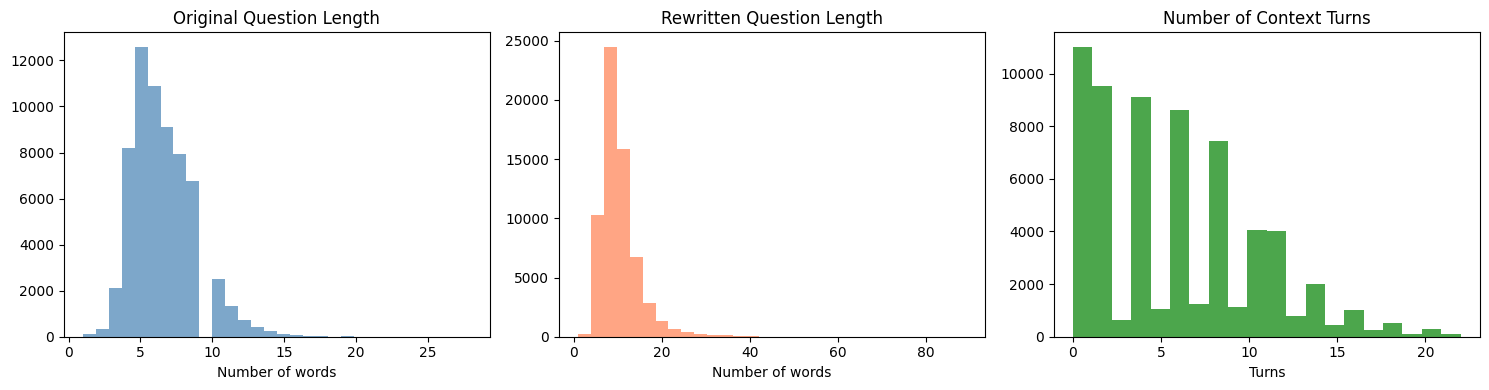

In [16]:
train_df['question_len'] = train_df['Question'].apply(lambda x: len(str(x).split()))
train_df['rewrite_len'] = train_df['Rewrite'].apply(lambda x: len(str(x).split()))
train_df['context_turns'] = train_df['Context'].apply(lambda x: len(x))

print("=== Dataset Statistics ===")
print(f"Avg original question length : {train_df['question_len'].mean():.1f} words")
print(f"Avg rewritten question length: {train_df['rewrite_len'].mean():.1f} words")
print(f"Avg context turns            : {train_df['context_turns'].mean():.1f}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(train_df['question_len'], bins=30, color='steelblue', alpha=0.7)
axes[0].set_title('Original Question Length')
axes[0].set_xlabel('Number of words')

axes[1].hist(train_df['rewrite_len'], bins=30, color='coral', alpha=0.7)
axes[1].set_title('Rewritten Question Length')
axes[1].set_xlabel('Number of words')

axes[2].hist(train_df['context_turns'], bins=20, color='green', alpha=0.7)
axes[2].set_title('Number of Context Turns')
axes[2].set_xlabel('Turns')

plt.tight_layout()
plt.savefig('qrecc_analysis.png', dpi=150)
plt.show()

In [17]:
ambiguity_words = ['it', 'they', 'he', 'she', 'this', 'that', 'these', 'those', 'there']

def ambiguity_score(question):
    words = str(question).lower().split()
    return sum(1 for w in words if w in ambiguity_words)

train_df['ambiguity_score'] = train_df['Question'].apply(ambiguity_score)

print("=== Top 5 Most Ambiguous Questions ===")
top = train_df.nlargest(5, 'ambiguity_score')[['Question', 'Rewrite', 'ambiguity_score']]
for _, row in top.iterrows():
    print(f"\nOriginal : {row['Question']}")
    print(f"Rewrite  : {row['Rewrite']}")
    print(f"Score    : {row['ambiguity_score']}")

=== Top 5 Most Ambiguous Questions ===

Original : Was there anything else that he did that was artistic?
Rewrite  : Was there anything else that Lawrence Alma-Tadema did that was artistic?
Score    : 4

Original : Do they know how long she had been there before she was found?
Rewrite  : Do the authorities know how long Black Dahlia's body had been in Leimert Park before she was found?
Score    : 4

Original : Was there any significant events that emerged as a result of that that was mentioned?
Rewrite  : Was there any significant events that emerged as a result of Stan Laurel's multiple marriages mentioned?
Score    : 4

Original : are there any facts that stood out to you in this article that you found interesting?
Rewrite  : Are there any facts that stood out to you in this Uhuru Kenyatta article that you found interesting?
Score    : 4

Original : What does it mean that they don't match those of her peers?
Rewrite  : what does The Hollywood Reporter mean that Taylor Swift's vocals 

In [18]:
tokenizer = T5Tokenizer.from_pretrained("t5-small")
model = T5ForConditionalGeneration.from_pretrained("t5-small")

device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)
print(f"Model loaded on: {device}")

Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

Model loaded on: cpu


In [19]:
def rewrite_question(context, question, max_length=64):
    context_str = ' ||| '.join(context[-3:])
    input_text = f"rewrite question: {question} context: {context_str}"

    inputs = tokenizer(
        input_text,
        return_tensors="pt",
        max_length=512,
        truncation=True
    ).to(device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_length=max_length,
            num_beams=4,
            early_stopping=True
        )

    return tokenizer.decode(outputs[0], skip_special_tokens=True)

In [20]:
def dialogue_clarity_score(original, rewritten, context):
    orig_words = set(str(original).lower().split())
    rew_words = set(str(rewritten).lower().split())
    context_words = set(' '.join(context).lower().split())

    ambig = {'it','they','he','she','this','that','these','those','there'}
    stopwords = {'the','a','an','is','are','was','were','do','does','did','of','in','on','at'}

    orig_ambig = len(orig_words & ambig)
    rew_ambig = len(rew_words & ambig)
    ambiguity_reduction = max(0, (orig_ambig - rew_ambig) / (orig_ambig + 1))

    orig_keywords = orig_words - stopwords - ambig
    preservation = len(orig_keywords & rew_words) / (len(orig_keywords) + 1)

    new_words = rew_words - orig_words
    enrichment = len(new_words & context_words) / (len(new_words) + 1)

    return round(0.4 * ambiguity_reduction + 0.3 * preservation + 0.3 * enrichment, 4)

In [21]:
print("Evaluating on 30 examples...")
eval_sample = test_df.sample(30, random_state=42)

generated_list = []
reference_list = []
dcs_list = []

for i, (_, row) in enumerate(eval_sample.iterrows()):
    generated = rewrite_question(row['Context'], row['Question'])
    dcs = dialogue_clarity_score(row['Question'], generated, row['Context'])
    generated_list.append(generated)
    reference_list.append(row['Rewrite'])
    dcs_list.append(dcs)

bleu = BLEU()
bleu_result = bleu.corpus_score(generated_list, [reference_list])

print(f"\n=== Evaluation Results ===")
print(f"BLEU Score : {bleu_result.score:.2f}")
print(f"DCS mean   : {np.mean(dcs_list):.4f}")
print(f"DCS min    : {np.min(dcs_list):.4f}")
print(f"DCS max    : {np.max(dcs_list):.4f}")

Evaluating on 30 examples...

=== Evaluation Results ===
BLEU Score : 5.58
DCS mean   : 0.2826
DCS min    : 0.0000
DCS max    : 0.5367


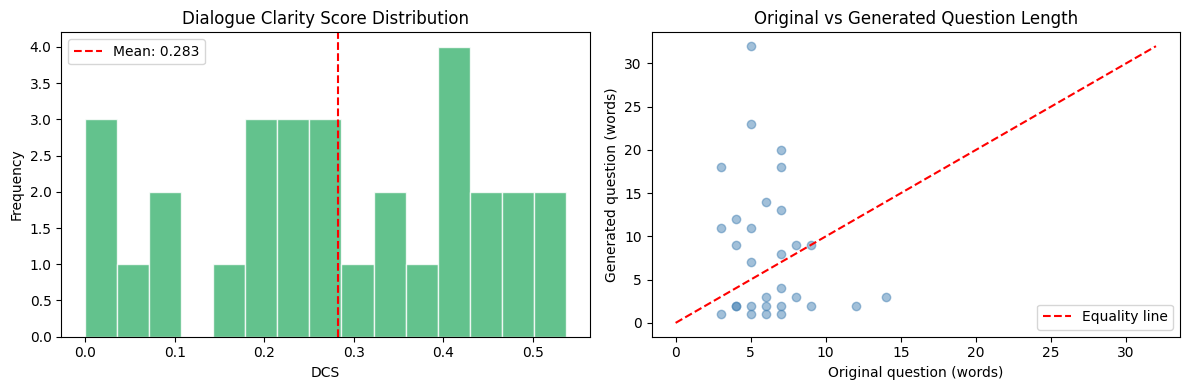

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(dcs_list, bins=15, color='mediumseagreen', alpha=0.8, edgecolor='white')
axes[0].axvline(np.mean(dcs_list), color='red', linestyle='--',
                label=f'Mean: {np.mean(dcs_list):.3f}')
axes[0].set_title('Dialogue Clarity Score Distribution')
axes[0].set_xlabel('DCS')
axes[0].set_ylabel('Frequency')
axes[0].legend()

orig_lens = [len(str(r['Question']).split()) for _, r in eval_sample.iterrows()]
gen_lens = [len(g.split()) for g in generated_list]

axes[1].scatter(orig_lens, gen_lens, alpha=0.5, color='steelblue')
max_val = max(max(orig_lens), max(gen_lens))
axes[1].plot([0, max_val], [0, max_val], 'r--', label='Equality line')
axes[1].set_title('Original vs Generated Question Length')
axes[1].set_xlabel('Original question (words)')
axes[1].set_ylabel('Generated question (words)')
axes[1].legend()

plt.tight_layout()
plt.savefig('qrecc_results.png', dpi=150)
plt.show()

In [23]:
def process(context_text, question):
    context = [c.strip() for c in context_text.split("|||") if c.strip()]
    rewritten = rewrite_question(context, question)
    dcs = dialogue_clarity_score(question, rewritten, context)
    return rewritten, str(dcs)

demo = gr.Interface(
    fn=process,
    inputs=[
        gr.Textbox(
            label="Conversation Context",
            placeholder="Turn 1 ||| Turn 2 ||| Turn 3",
            lines=3
        ),
        gr.Textbox(
            label="Ambiguous Question",
            placeholder="e.g. What are its effects?"
        )
    ],
    outputs=[
        gr.Textbox(label="Rewritten Question"),
        gr.Textbox(label="Dialogue Clarity Score (DCS)")
    ],
    title="Conversational Question Rewriter",
    description="Enter conversation context (separated by |||) and an ambiguous question. The system will rewrite it using T5 and evaluate clarity with our custom DCS metric."
)

demo.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://5f30dfa737d4c33703.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
